Section 1: Define the learning problem

In Markdown:

Given a grayscale image of a handwritten digit, predict which of the ten digit classes $0,\ldots,9$ it represents.

Mathematically:

$$ f_\theta(x_i)=\hat{y}_i $$

where:

-$x_i$ is the $i$-th handwritten-digit image.
- Section 1: Define the learning problem

In Markdown:

Given a grayscale image of a handwritten digit, predict which of the ten digit classes $0,\ldots,9$ it represents.

Mathematically:

$$ f_\theta(x_i)=\hat{y}_i $$

where:

-$x_i$ is the $i$-th handwritten-digit image.
- $y_i$ is its correct class label.
- $\hat{y}_i$ is the model's predicted class.
- $\theta$ represents all trainable weights and biases.

This carries forward the notation you have already been using.y_i$ is its correct class label.
- $\hat{y}_i$ is the model's predicted class.
- $\theta$ represents all trainable weights and biases.

This carries forward the notation you have already been using.

Section 2: Load and inspect the data

In [8]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

Inspect before transforming anything:

In [9]:
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

print("Image dtype:", train_images.dtype)
print("First label:", train_labels[0])

train_images: (60000, 28, 28)
train_labels: (60000,)
test_images: (10000, 28, 28)
test_labels: (10000,)
Image dtype: uint8
First label: 5


## Section 3: Examine one training observation

The first training observation is:

$$
r_0\in\mathbb{R}^{28\times28}
$$

It is a matrix containing 784 pixel-intensity values. Its corresponding
target is:

$$
y_0=5
$$

At this stage, $r_0$ is still raw input. Later, preprocessing will produce
the model-ready input:

$$
x_0=P(r_0)
$$

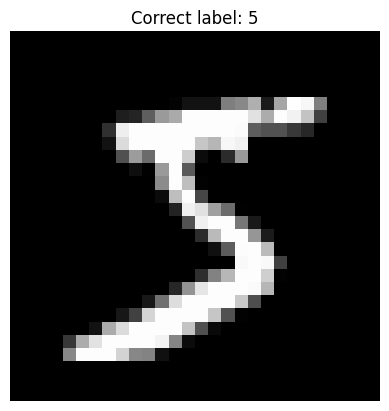

In [10]:
import matplotlib.pyplot as plt

sample_index = 0

plt.imshow(train_images[sample_index], cmap="gray")
plt.title(f"Correct label: {train_labels[sample_index]}")
plt.axis("off")
plt.show()

In [11]:
first_image = train_images[0]

print("Shape:", first_image.shape)
print("Data type:", first_image.dtype)
print("Minimum pixel value:", first_image.min())
print("Maximum pixel value:", first_image.max())

first_image

Shape: (28, 28)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

This is the actual matrix:

This establishes the precise chain:

$$ r_0 = \text{one raw }28\times28\text{ image} $$ $$ y_0=5 $$
x
0
	​
=P(r0)
	

)=the processed numerical input given to the network

## Section 4: Preprocess the images

Let the raw $i$-th image be:

$$
r_i \in \{0,1,\ldots,255\}^{28\times28}
$$

The preprocessing function $P$ performs two operations:

1. Flatten the $28\times28$ matrix into a vector of 784 values.
2. Scale each pixel value from $0\ldots255$ to $0\ldots1$.

Therefore:

$$
x_i=P(r_i)
$$

and:

$$
x_i\in[0,1]^{784}
$$

For the complete training set:

$$
X_{\text{train}}\in[0,1]^{60000\times784}
$$

For the complete test set:

$$
X_{\text{test}}\in[0,1]^{10000\times784}
$$

In [28]:
x_train = train_images.reshape((train_images.shape[0], 28 * 28))
x_test = test_images.reshape((test_images.shape[0], 28 * 28))

print("Before reshaping:")
print("train_images:", train_images.shape)
print("test_images: ", test_images.shape)

print("\nAfter reshaping:")
print("x_train:", x_train.shape)
print("x_test: ", x_test.shape)

Before reshaping:
train_images: (60000, 28, 28)
test_images:  (10000, 28, 28)

After reshaping:
x_train: (60000, 784)
x_test:  (10000, 784)


The first dimension still counts observations:

$$ 60{,}000=\text{number of training images} $$

The remaining dimensions were flattened:

$$ 28\times28=784 $$

Therefore:

$$ (60{,}000,28,28)\longrightarrow(60{,}000,784) $$

No pixels were added or removed.

2. Inspect one flattened observation

In [29]:
print("Original first image shape:", train_images[0].shape)
print("Flattened first image shape:", x_train[0].shape)

print("\nFirst 30 flattened pixel values:")
print(x_train[0][:30])

Original first image shape: (28, 28)
Flattened first image shape: (784,)

First 30 flattened pixel values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


This compares:

$$ r_0\in\mathbb{R}^{28\times28} $$

with its flattened representation:

$$ x_0\in\mathbb{R}^{784} $$

At this moment, however, its values are still integers between 0 and 255. We have completed the flattening portion of \(P\), but not the scaling portion.

### Scale the pixel values

For each pixel value $p_j$:

$$
p_j^{\prime}=\frac{p_j}{255}
$$

Therefore:

$$
0 \leq p_j^{\prime} \leq 1
$$

Dividing by 255 changes the numerical scale, but not the information
represented by the image.

In [30]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print("x_train dtype:", x_train.dtype)
print("x_train shape:", x_train.shape)
print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())

x_train dtype: float32
x_train shape: (60000, 784)
Minimum value: 0.0
Maximum value: 1.0


4. Verify the complete data contract

In [31]:
assert x_train.shape == (60_000, 784)
assert x_test.shape == (10_000, 784)

assert x_train.dtype == "float32"
assert x_test.dtype == "float32"

assert x_train.min() >= 0
assert x_train.max() <= 1

print("Preprocessing checks passed.")

Preprocessing checks passed.


You have now implemented:

$$ x_i=P(r_i) $$

For this notebook:

$$ P(r_i) = \operatorname{scale} \left( \operatorname{flatten}(r_i) \right) $$

The raw and processed representations are now:

Property	Raw image \(r_i\)	Processed input \(x_i\)
Shape	\(28\times28\)	\(784\)
Data type	uint8	float32
Value range	\(0\ldots255\)	\(0\ldots1\)
Meaning	Grayscale image	Model-ready feature vector

The next step is Chollet’s actual network: the \(784\rightarrow512\rightarrow10\) architecture.

## Section 5: Build the neural network

Each processed image contains 784 input values:

$$
x_i \in \mathbb{R}^{784}
$$

The network has two Dense layers:

$$
784 \longrightarrow 512 \longrightarrow 10
$$

- The input contains 784 pixel features.
- The hidden layer contains 512 neurons using ReLU.
- The output layer contains 10 neurons using softmax.
- Each output neuron corresponds to one digit class from 0 through 9.

The number 512 is a model-design choice—a hyperparameter. It is not
calculated directly from the 784 inputs.

1. Create the network

In [32]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None means that Keras can accept different batch sizes. For example:

$$ (32,784)\rightarrow(32,512)\rightarrow(32,10) $$

would represent a batch of 32 images.

The first Dense layer

### Layer 1: The hidden Dense layer

Using our column-vector mathematical convention:

$$
z^{(1)} = W^{(1)}x_i+b^{(1)}
$$

$$
a^{(1)}=\operatorname{ReLU}\left(z^{(1)}\right)
$$

The shapes are:

$$
x_i \in \mathbb{R}^{784 \times 1}
$$

$$
W^{(1)} \in \mathbb{R}^{512 \times 784}
$$

$$
b^{(1)} \in \mathbb{R}^{512 \times 1}
$$

Therefore:

$$
z^{(1)},a^{(1)} \in \mathbb{R}^{512 \times 1}
$$

The matrix multiplication is valid because the inner dimensions match:

$$ \underbrace{(512\times784)}_{W^{(1)}} \underbrace{(784\times1)}_{x_i} = \underbrace{(512\times1)}_{z^{(1)}} $$

Each of the 512 neurons receives all 784 pixel values.

### Layer 2: The output layer

The second layer receives the 512 activations:

$$
z^{(2)}=W^{(2)}a^{(1)}+b^{(2)}
$$

$$
\hat{y}_i=\operatorname{softmax}\left(z^{(2)}\right)
$$

The shapes are:

$$
W^{(2)} \in \mathbb{R}^{10 \times 512}
$$

$$
b^{(2)} \in \mathbb{R}^{10 \times 1}
$$

Therefore:

$$
\hat{y}_i \in \mathbb{R}^{10 \times 1}
$$

The ten output values are probabilities whose sum is 1.

The output can be pictured as:

$$ \hat y_i= \begin{bmatrix} P(y_i=0)\\ P(y_i=1)\\ \vdots\\ P(y_i=9) \end{bmatrix} $$

The largest probability determines the predicted digit.

Inspect Keras’s weight shapes

In [33]:
for layer_number, layer in enumerate(model.layers, start=1):
    weights, biases = layer.get_weights()

    print(f"Layer {layer_number}: {layer.name}")
    print("  Keras weight shape:", weights.shape)
    print("  Bias shape:", biases.shape)

Layer 1: dense_2
  Keras weight shape: (784, 512)
  Bias shape: (512,)
Layer 2: dense_3
  Keras weight shape: (512, 10)
  Bias shape: (10,)


You may notice that Keras’s first weight shape is:

$$ (784,512) $$

while our handwritten convention uses:

$$ (512,784) $$

That is because our handwritten calculation uses a column vector:

$$ W^{(1)}x_i $$

Keras stores observations as rows and calculates an entire batch as:

$$ XK^{(1)}+b^{(1)} $$

Therefore:

$$ (60000,784)(784,512)=(60000,512) $$

The mathematics is equivalent; the matrices are oriented differently because Keras uses batch-first row storage.

At this checkpoint, the network exists, but it has not learned anything. Its 407,050 parameters are merely initialized values. The next step is to compile the network by selecting its loss function, optimizer, and evaluation metric.

## Section 6: Compile the network

Compiling specifies three important components:

1. **Loss function:** How wrong is the prediction?
2. **Optimizer:** How should the weights and biases be adjusted?
3. **Metric:** What measurement should be reported to us?

For MNIST, we use:

- Sparse categorical cross-entropy for the loss
- RMSprop for the optimizer
- Classification accuracy as a reporting metric

In [34]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

No output is expected. Compilation configures the training process; it does not train the model.

Why sparse categorical cross-entropy?

Our labels are integer class numbers:

In [35]:
print("First 10 labels:", train_labels[:10])
print("Label shape:", train_labels.shape)
print("Label dtype:", train_labels.dtype)
print("Smallest label:", train_labels.min())
print("Largest label:", train_labels.max())

First 10 labels: [5 0 4 1 9 2 1 3 1 4]
Label shape: (60000,)
Label dtype: uint8
Smallest label: 0
Largest label: 9


You should see labels such as:

[5 0 4 1 9 2 1 3 1 4]

Each label is one integer:

$$ y_i\in\{0,1,\ldots,9\} $$

For the first image:

$$ y_0=5 $$

The model produces ten probabilities:

$$ \hat y_0= \begin{bmatrix} P(0)\\ P(1)\\ P(2)\\ P(3)\\ P(4)\\ P(5)\\ P(6)\\ P(7)\\ P(8)\\ P(9) \end{bmatrix} $$

Because the correct label is 5, the loss examines the model’s probability for class 5:

L
0
	​

=−log(
y
^
	​

0,5
	​

)

### Sparse categorical cross-entropy

For observation $i$, let $y_i$ be the correct class.

The loss is:

$$
L_i=-\log\left(\hat{y}_{i,y_i}\right)
$$

This means that the loss examines the predicted probability assigned to
the correct class.

For a batch containing $m$ observations, the average loss is:

$$
L=\frac{1}{m}\sum_{i=1}^{m}L_i
$$

A small numerical example

Suppose the correct digit is 5.

If the model gives class 5 a probability of \(0.80\):

$$ L=-\log(0.80)\approx0.223 $$

That is a relatively small loss.

If it gives class 5 a probability of \(0.10\):

$$ L=-\log(0.10)\approx2.303 $$

That is a much larger loss.

The model is therefore rewarded for assigning a high probability to the correct digit.

Why is it called “sparse”?

The target is stored as a single integer:

$$ y_0=5 $$

It is not stored as a ten-element one-hot vector:

$$ \begin{bmatrix} 0&0&0&0&0&1&0&0&0&0 \end{bmatrix} $$

Both encodings can represent the same target, but they require different Keras loss names:

Target representation	Keras loss
Integer such as 5	sparse_categorical_crossentropy
One-hot vector	categorical_crossentropy

MNIST’s labels are integers, so the sparse version is appropriate.

What RMSprop does

The loss gives us one number describing the current error. Backpropagation calculates its gradients:

$$ \nabla_\theta L $$

where \(\theta\) represents all weights and biases.

The optimizer uses those gradients to update the parameters:

$$ \theta_{\text{new}} = \theta_{\text{old}} - \text{adjusted gradient} $$

RMSprop is an adaptive optimizer: it scales updates using a running average of recent squared gradients. We will examine its details later; for this first book example, its job is:

$$ \text{loss}\rightarrow \text{gradients}\rightarrow \text{parameter updates} $$
Accuracy is not the loss

Accuracy reports the proportion classified correctly:

$$ \text{accuracy} = \frac{\text{correct predictions}} {\text{total predictions}} $$

The optimizer uses cross-entropy loss to learn. Accuracy is primarily reported so we can interpret performance.

At this point:

The data has been preprocessed.
The architecture has been constructed.
The loss and optimizer have been selected.
The model still has not learned.

The next step is model.fit(), where Keras repeatedly performs the forward pass, loss calculation, backpropagation, and parameter update.

This next point is where the model begins learning from the 60,000 training images with model.fit()

## Section 7: Train the network

Training repeatedly performs the following cycle:

1. Select a batch of training observations.
2. Calculate predictions with a forward pass.
3. Compare the predictions with the correct labels.
4. Calculate the loss.
5. Calculate gradients through backpropagation.
6. Update the weights and biases with the optimizer.

In compact form:

$$
X_{\text{batch}}
\rightarrow
\hat{Y}_{\text{batch}}
\rightarrow
L
\rightarrow
\nabla_{\theta}L
\rightarrow
\theta_{\text{new}}
$$

In [41]:
history = model.fit(
    x_train,
    train_labels,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0071
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9990 - loss: 0.0049
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0032
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0023
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 0.0015


What is one batch?

The batch size is 128:

$$ X_{\text{batch}}\in\mathbb{R}^{128\times784} $$

The corresponding labels have shape:

$$ y_{\text{batch}}\in\{0,\ldots,9\}^{128} $$

The forward pass transforms the batch:

$$ (128,784) \rightarrow (128,512) \rightarrow (128,10) $$

The final tensor contains ten probabilities for each of the 128 images:

$$ \hat Y_{\text{batch}}\in\mathbb{R}^{128\times10} $$

After calculating the batch loss, Keras updates all 407,050 trainable parameters once.

Why does each epoch have 469 steps?

There are 60,000 training images and 128 images per batch:

$$ \frac{60{,}000}{128}=468.75 $$

Keras therefore needs 469 batches to process the entire training set:

$$ \left\lceil\frac{60{,}000}{128}\right\rceil=469 $$

The final batch is smaller because 60,000 is not evenly divisible by 128.

What is one epoch?

One epoch means that the model has processed every training observation once.

With five epochs:

$$ 60{,}000\times5=300{,}000 $$

training-example presentations occur.

This does not mean there are 300,000 different images. The same 60,000 images are revisited five times while the parameters continue to improve.

Examine the training history

history.history is a Python dictionary containing the measurements recorded after each epoch.

In [42]:
print(history.history.keys())
print("Loss by epoch:", history.history["loss"])
print("Accuracy by epoch:", history.history["accuracy"])

dict_keys(['accuracy', 'loss'])
Loss by epoch: [0.007411686237901449, 0.00524291442707181, 0.003564275335520506, 0.0025140508078038692, 0.0016236713854596019]
Accuracy by epoch: [0.9984666705131531, 0.9988833069801331, 0.9994166493415833, 0.9994999766349792, 0.9998000264167786]


Now let's plot them.

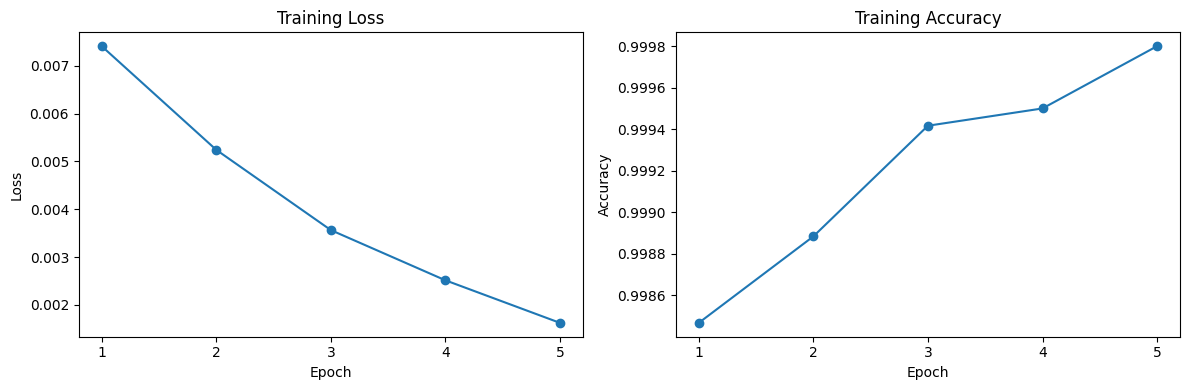

In [44]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["accuracy"], marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)

plt.tight_layout()
plt.show()

The expected pattern is:

$$ \text{loss decreases} $$

while:

$$ \text{training accuracy increases} $$

That provides evidence that the optimizer is finding parameter values that better fit the training data.

One important notebook behavior

If you run the model.fit() cell again, Keras does not start over. It continues training the model from its current weights.

Therefore, running the five-epoch cell twice effectively gives the model ten epochs of training, although the second history object contains only the later five.

The next step is crucial: evaluate the trained model on x_test and test_labels, which the optimizer has never used. That will distinguish learning the training data from generalizing to unseen images.

## Section 8: Evaluate the trained model

The training set was used to learn the parameters:

Training accuracy tells us how well the model fits examples it learned from. Test accuracy measures how well it generalizes to 10,000 images that were not used to update its parameters.

$$
\theta=(W^{(1)},b^{(1)},W^{(2)},b^{(2)})
$$

The test set was not used during parameter updates.

Evaluation performs a forward pass:

$$
X_{\text{test}}
\rightarrow
\hat{Y}_{\text{test}}
\rightarrow
L_{\text{test}}
$$

It calculates test loss and accuracy, but does not perform backpropagation
or update the model's parameters.

In [48]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    test_labels
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy percentage: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9806 - loss: 0.0799
Test loss: 0.0664
Test accuracy: 0.9836
Test accuracy percentage: 98.36%


You should probably see test accuracy around 97–98%, although your exact result may vary.

Compare training and test performance

In [49]:
final_train_loss = history.history["loss"][-1]
final_train_accuracy = history.history["accuracy"][-1]

accuracy_gap = final_train_accuracy - test_accuracy

print(f"Final training loss:     {final_train_loss:.4f}")
print(f"Test loss:               {test_loss:.4f}")
print()
print(f"Final training accuracy: {final_train_accuracy:.4f}")
print(f"Test accuracy:           {test_accuracy:.4f}")
print(f"Generalization gap:      {accuracy_gap:.4f}")

Final training loss:     0.0016
Test loss:               0.0664

Final training accuracy: 0.9998
Test accuracy:           0.9836
Generalization gap:      0.0162


The generalization gap is:

$$ \text{gap} = \text{training accuracy} - \text{test accuracy} $$

For example:

$$ 0.989-0.978=0.011 $$

That would be a gap of:

$$ 1.1\text{ percentage points} $$

A small difference is normal. A large difference—very high training accuracy but substantially lower test accuracy—can indicate overfitting.

The important distinction
Operation	Training	Testing
Forward pass	Yes	Yes
Calculate loss	Yes	Yes
Calculate gradients	Yes	No
Update parameters	Yes	No
Measure performance	Yes	Yes

In mathematical form, training changes the parameters:

$$ \theta_{\text{old}}\rightarrow\theta_{\text{new}} $$

Evaluation holds them fixed:

$$ \theta_{\text{after evaluation}} = \theta_{\text{before evaluation}} $$

The next step is to ask the model for the ten probabilities for one specific test image and compare its predicted digit with the correct label.

## Section 9: Make a prediction

Now we use the trained model for inference: provide an unseen image and receive ten class probabilities.

For one processed test image:

$$
x_i \in \mathbb{R}^{784}
$$

the trained model calculates:

$$
\hat{y}_i=f_\theta(x_i)
$$

The prediction contains ten probabilities:

$$
\hat{y}_i \in [0,1]^{10}
$$

The predicted digit is the position containing the largest probability:

$$
\hat{c}_i=\operatorname{argmax}(\hat{y}_i)
$$

## 1. Select one test image

In [50]:
import numpy as np
import matplotlib.pyplot as plt

sample_index = 0

raw_image = test_images[sample_index]
processed_image = x_test[sample_index]
actual_class = test_labels[sample_index]

print("Raw image shape:", raw_image.shape)
print("Processed image shape:", processed_image.shape)
print("Actual class:", actual_class)

Raw image shape: (28, 28)
Processed image shape: (784,)
Actual class: 7


## 2. Add the batch dimension

Keras expects a batch of observations, even when predicting only one image.

In [51]:
sample_batch = x_test[sample_index : sample_index + 1]

print("Single observation shape:", processed_image.shape)
print("One-observation batch shape:", sample_batch.shape)

Single observation shape: (784,)
One-observation batch shape: (1, 784)


The shape changes from:

$$ (784,) $$

to:

$$ (1,784) $$

The first dimension now means:

$$ 1=\text{one observation in the batch} $$
## 3. Calculate the probabilities

In [53]:
prediction_batch = model.predict(sample_batch, verbose=0)
probabilities = prediction_batch[0]

print("Prediction batch shape:", prediction_batch.shape)
print("Probability vector shape:", probabilities.shape)
print()
print("Probabilities:")
print(probabilities)
print()
print("Probability sum:", probabilities.sum())

Prediction batch shape: (1, 10)
Probability vector shape: (10,)

Probabilities:
[2.8785465e-11 2.4613598e-13 7.1245662e-11 4.8472835e-08 5.0484560e-17
 3.1645747e-13 1.1665152e-18 1.0000000e+00 1.7267975e-11 2.9790528e-09]

Probability sum: 1.0


The probabilities should sum to approximately 1:

$$ \sum_{k=0}^{9}\hat y_{i,k}\approx1 $$
## 4. Select the predicted class

In [54]:
predicted_class = np.argmax(probabilities)
confidence = probabilities[predicted_class]

print("Predicted class:", predicted_class)
print("Actual class:   ", actual_class)
print(f"Confidence:      {confidence:.4f}")

Predicted class: 7
Actual class:    7
Confidence:      1.0000


np.argmax() returns the position of the largest probability.

For example, if the largest value is at position 7:

$$ \operatorname{argmax}(\hat y_i)=7 $$

then the predicted digit is 7.

Visualize the image and probabilities

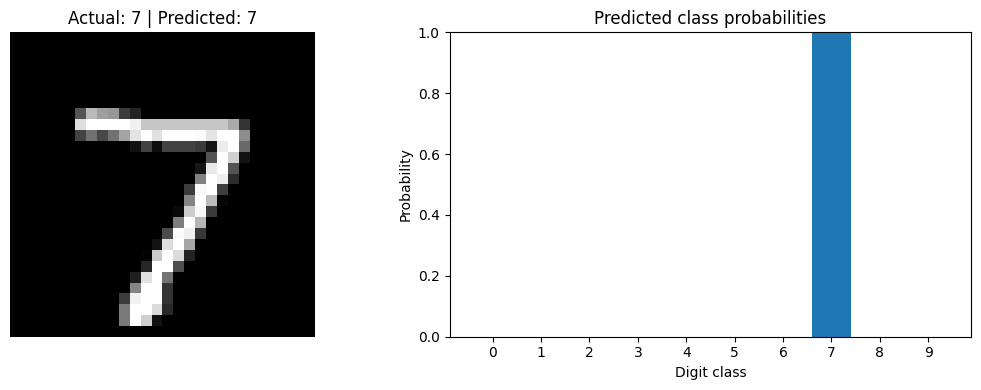

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(raw_image, cmap="gray")
axes[0].set_title(
    f"Actual: {actual_class} | Predicted: {predicted_class}"
)
axes[0].axis("off")

axes[1].bar(range(10), probabilities)
axes[1].set_title("Predicted class probabilities")
axes[1].set_xlabel("Digit class")
axes[1].set_ylabel("Probability")
axes[1].set_xticks(range(10))
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

This completes the inference chain:

$$ r_i \xrightarrow{P} x_i \xrightarrow{f_\theta} \hat y_i \xrightarrow{\operatorname{argmax}} \hat c_i $$

Notice what does not occur during inference:

No correct label is provided to the model.
No loss is needed to produce the prediction.
No backpropagation occurs.
No weights or biases are updated.

The correct label is used afterward only to determine whether the prediction was right. The next step is to inspect several correct and incorrect predictions so accuracy becomes something visible rather than only a single percentage.

## Section 10: Inspect incorrect predictions

An overall accuracy such as 98% hides the specific images the model misunderstood. Error analysis makes those failures visible.
For every test observation, the model produces a predicted class:

$$
\hat{c}_i=\operatorname{argmax}\left(f_\theta(x_i)\right)
$$

A prediction is incorrect when:

$$
\hat{c}_i \neq y_i
$$

The set of incorrectly classified observations is:

$$
E=\{i:\hat{c}_i \neq y_i\}
$$

The test error rate is:

$$
\text{error rate}
=
\frac{|E|}{N_{\text{test}}}
$$

## 1. Predict all 10,000 test images

In [56]:
test_probabilities = model.predict(x_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

print("Probability tensor shape:", test_probabilities.shape)
print("Prediction vector shape:", test_predictions.shape)

Probability tensor shape: (10000, 10)
Prediction vector shape: (10000,)


Expected shapes:

Probability tensor shape: (10000, 10)
Prediction vector shape: (10000,)

(10000,784)→(10000,10)

Then argmax(axis=1) converts each row of ten probabilities into one predicted digit:

$$ (10000,10) \rightarrow (10000,) $$
## 2. Find the incorrect predictions

In [57]:
incorrect_indices = np.where(test_predictions != test_labels)[0]

number_incorrect = len(incorrect_indices)
number_correct = len(test_labels) - number_incorrect
error_rate = number_incorrect / len(test_labels)

print("Correct predictions:", number_correct)
print("Incorrect predictions:", number_incorrect)
print(f"Error rate: {error_rate:.4f}")
print(f"Accuracy: {(1 - error_rate):.4f}")

Correct predictions: 9836
Incorrect predictions: 164
Error rate: 0.0164
Accuracy: 0.9836


The relationship is:

$$ \text{accuracy}+\text{error rate}=1 $$

For example, 98% accuracy corresponds to approximately 2% error.

## 3. Display several mistakes

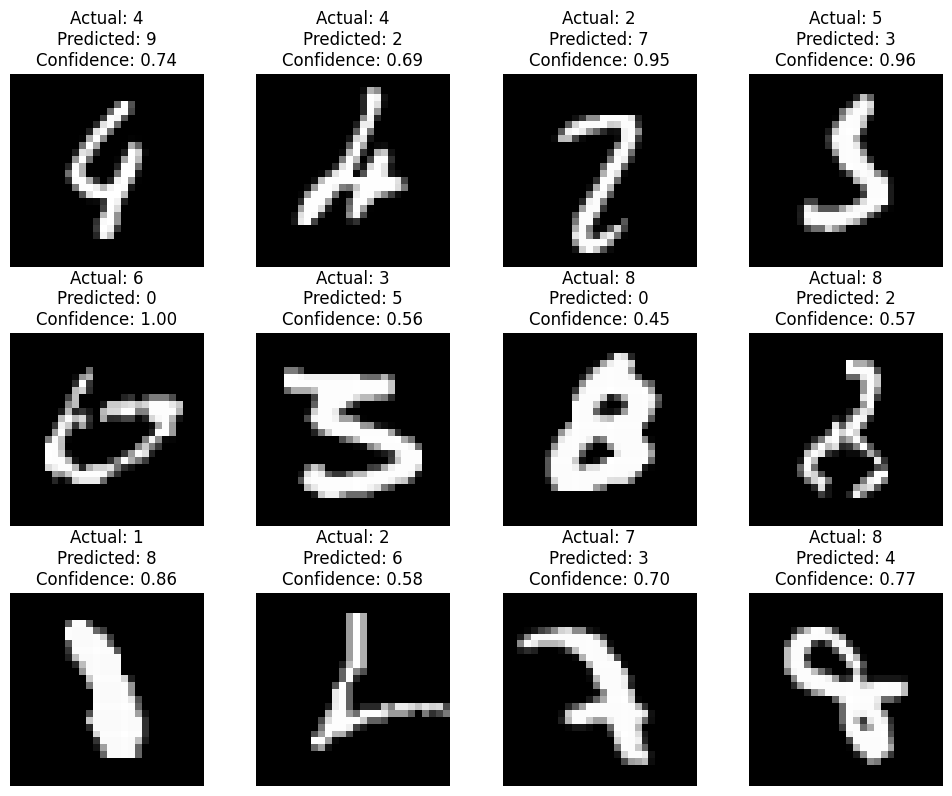

In [ ]:
number_to_display = 12
selected_errors = incorrect_indices[:number_to_display]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for axis, index in zip(axes, selected_errors):
    predicted = test_predictions[index]
    actual = test_labels[index]
    confidence = test_probabilities[index, predicted]

    axis.imshow(test_images[index], cmap="gray")
    axis.set_title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

Look at the images as a human reviewer:

Is the handwriting ambiguous?
Does one digit resemble another?
Is the digit unusually tilted or incomplete?
Was the model highly confident even though it was wrong?

The last question is important. The largest softmax value is often called confidence, but it is not automatically a perfectly calibrated probability of being correct.

## 4. Create a confusion matrix

A confusion matrix summarizes which digit pairs are most commonly confused.

In [60]:
import tensorflow as tf

confusion_matrix = tf.math.confusion_matrix(
    test_labels,
    test_predictions,
    num_classes=10
).numpy()

print(confusion_matrix)

[[ 970    0    1    0    0    1    4    1    2    1]
 [   0 1125    3    1    0    0    2    1    3    0]
 [   5    0 1011    2    1    0    2    7    4    0]
 [   0    0    2  993    0    3    0    2    2    8]
 [   1    0    2    1  961    0    5    3    0    9]
 [   2    0    0    6    1  874    3    1    4    1]
 [   4    2    0    1    3    3  943    0    2    0]
 [   0    0    6    1    0    0    0 1014    4    3]
 [   2    1    1    3    4    2    1    3  955    2]
 [   1    2    1    2    5    1    1    4    2  990]]


### Display it visually:

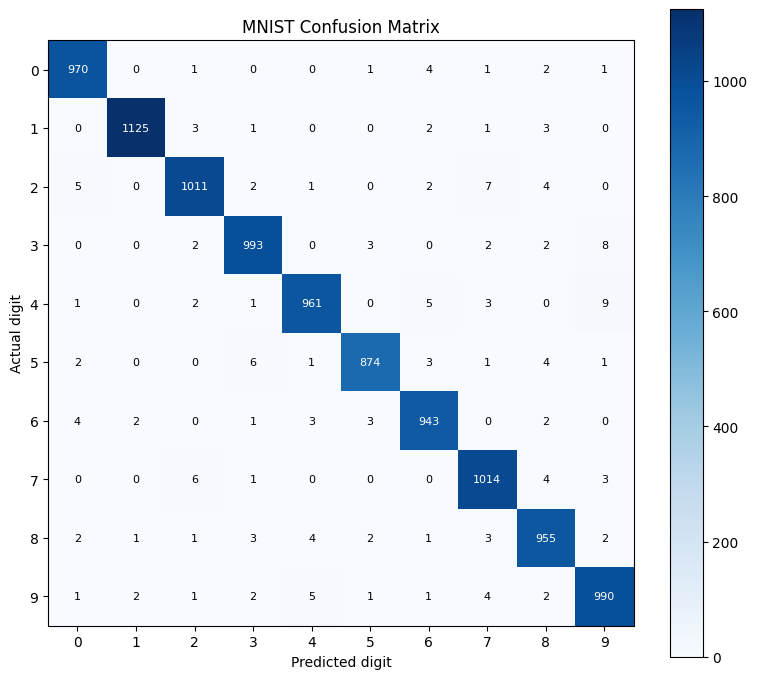

In [61]:
fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(confusion_matrix, cmap="Blues")
plt.colorbar(image, ax=ax)

ax.set_title("MNIST Confusion Matrix")
ax.set_xlabel("Predicted digit")
ax.set_ylabel("Actual digit")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

for actual in range(10):
    for predicted in range(10):
        count = confusion_matrix[actual, predicted]

        color = (
            "white"
            if count > confusion_matrix.max() / 2
            else "black"
        )

        ax.text(
            predicted,
            actual,
            count,
            ha="center",
            va="center",
            color=color,
            fontsize=8
        )

plt.tight_layout()
plt.show()

Read the matrix as:

Rows represent actual digits.
Columns represent predicted digits.
The diagonal contains correct classifications.
Off-diagonal cells contain mistakes.

For example, the cell at row 4, column 9 means:

$$ \text{actual digit }4 \quad\text{predicted as }9 $$

This completes a full first machine-learning workflow:

$$ \text{raw data} \rightarrow \text{preprocessing} \rightarrow \text{model} \rightarrow \text{loss} \rightarrow \text{training} \rightarrow \text{evaluation} \rightarrow \text{inference} \rightarrow \text{error analysis} $$

The next step is to finish this notebook with a concise mathematical model-design summary, then move into the Chapter 4 IMDB binary-classification notebook and compare its design decisions with MNIST.

## Section 11: Model-design summary

This final section records the entire MNIST experiment in your reusable model-design blueprint.

### 1. Learning task

Given a grayscale handwritten-digit image, predict one of ten classes:

$$
y_i \in \{0,1,\ldots,9\}
$$

This is a single-label multiclass classification problem.

### 2. Raw observation

Each raw image is a 28-by-28 matrix of integer pixel values:

$$
r_i \in \{0,1,\ldots,255\}^{28 \times 28}
$$

### 3. Preprocessing

The preprocessing function flattens and scales the image:

$$
x_i=P(r_i)
$$

$$
P(r_i)
=
\frac{\operatorname{flatten}(r_i)}{255}
$$

Therefore:

$$
x_i \in [0,1]^{784}
$$

### 4. First Dense layer

$$
z_i^{(1)}=W^{(1)}x_i+b^{(1)}
$$

$$
a_i^{(1)}=\operatorname{ReLU}\left(z_i^{(1)}\right)
$$

with:

$$
W^{(1)}\in\mathbb{R}^{512 \times 784}
$$

$$
b^{(1)}\in\mathbb{R}^{512 \times 1}
$$

$$
a_i^{(1)}\in\mathbb{R}^{512 \times 1}
$$

### 5. Output layer

$$
z_i^{(2)}=W^{(2)}a_i^{(1)}+b^{(2)}
$$

$$
\hat{y}_i=\operatorname{softmax}\left(z_i^{(2)}\right)
$$

with:

$$
W^{(2)}\in\mathbb{R}^{10 \times 512}
$$

$$
b^{(2)}\in\mathbb{R}^{10 \times 1}
$$

$$
\hat{y}_i\in[0,1]^{10}
$$

The output probabilities satisfy:

$$
\sum_{k=0}^{9}\hat{y}_{i,k}=1
$$

### 6. Predicted class

$$
\hat{c}_i=\operatorname{argmax}(\hat{y}_i)
$$

### 7. Loss

Because the targets are integer class labels, the model uses sparse
categorical cross-entropy:

$$
L_i=-\log\left(\hat{y}_{i,y_i}\right)
$$

For a batch of size $m$:

$$
L=\frac{1}{m}\sum_{i=1}^{m}L_i
$$

### 8. Learning

Backpropagation calculates the gradient:

$$
\nabla_\theta L
$$

RMSprop uses the gradient to update the parameters:

$$
\theta_{\text{old}}
\rightarrow
\theta_{\text{new}}
$$

where:

$$
\theta=
\left(
W^{(1)},b^{(1)},W^{(2)},b^{(2)}
\right)
$$

### 9. Evaluation

Training data is used to update the parameters. Test data is used only
to measure generalization.

The complete pipeline is:

$$
r_i
\xrightarrow{P}
x_i
\xrightarrow{f_\theta}
\hat{y}_i
\xrightarrow{\operatorname{argmax}}
\hat{c}_i
$$

### MNIST design decisions

| Decision | MNIST choice |
|---|---|
| Input modality | Grayscale image |
| Raw observation | 28-by-28 pixel matrix |
| Processed representation | 784-element scaled vector |
| Learning task | Single-label multiclass classification |
| Number of classes | 10 |
| Target encoding | Integer from 0 through 9 |
| Hidden architecture | Dense layer with 512 neurons |
| Hidden activation | ReLU |
| Output neurons | 10 |
| Output activation | Softmax |
| Loss function | Sparse categorical cross-entropy |
| Optimizer | RMSprop |
| Primary metric | Accuracy |
| Training epochs | 5 |
| Batch size | 128 |

### Optional: Save the trained model (if you want to save these trained weights)

In [62]:
model.save("mnist_dense_model.keras")

print("Model saved.")

Model saved.


Later it can be restored without retraining

In [63]:
restored_model = keras.models.load_model("mnist_dense_model.keras")

You have now completed Chollet’s first end-to-end neural-network example while connecting every major operation to your mathematical notation.

The important conceptual achievement is not merely classifying digits. You now have a reusable design sequence:

$$ \boxed{ \text{task} \rightarrow \text{data contract} \rightarrow P \rightarrow f_\theta \rightarrow \text{output representation} \rightarrow \text{loss} \rightarrow \text{optimization} \rightarrow \text{evaluation} } $$

Next, we can begin the Chapter 4 IMDB notebook and compare it directly with MNIST. The architecture and loss will change because IMDB is binary classification and its raw observations are text rather than images.